# 02_Segmentation_and_Tuning.ipynb
**Mục tiêu:** Trình diễn cách tìm ra tham số tối ưu và chứng minh kiến trúc K-Means + Snakes là tốt nhất.

## 0. Setup môi trường & Nạp ảnh đã tiền xử lý

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(r'd:\Computer Vision Final Project\Src code')
from src.preprocessing import apply_circular_mask, remove_hair, enhance_contrast_clahe, boost_faint_edges
from src.segmentation import get_otsu_mask, get_kmeans_mask, get_snakes_mask
from src.evaluation import calculate_iou
def draw_contour(image, mask, color):
    res = image.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(res, contours, -1, color, 2)
    return cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
img = cv2.imread(r'd:\Computer Vision Final Project\Src code\data\train\images\ISIC_0000029.jpg')
img = cv2.resize(img, (600, 450))
gt_mask = cv2.imread(r'd:\Computer Vision Final Project\Src code\data\train\masks\ISIC_0000029_segmentation.png', 0)
gt_mask = cv2.resize(gt_mask, (600, 450))
clean_img, _ = remove_hair(apply_circular_mask(img, 0.85), 15, 3)
clahe_color, clahe_gray = enhance_contrast_clahe(clean_img, 1.1)
smooth_l = apply_circular_mask(cv2.GaussianBlur(boost_faint_edges(clahe_gray)[0], (5, 5), 0), 0.85)
clahe_color = apply_circular_mask(clahe_color, 0.85)


## 1. Khảo sát tham số K-Means ($K = 2, 3, 4, 5$)

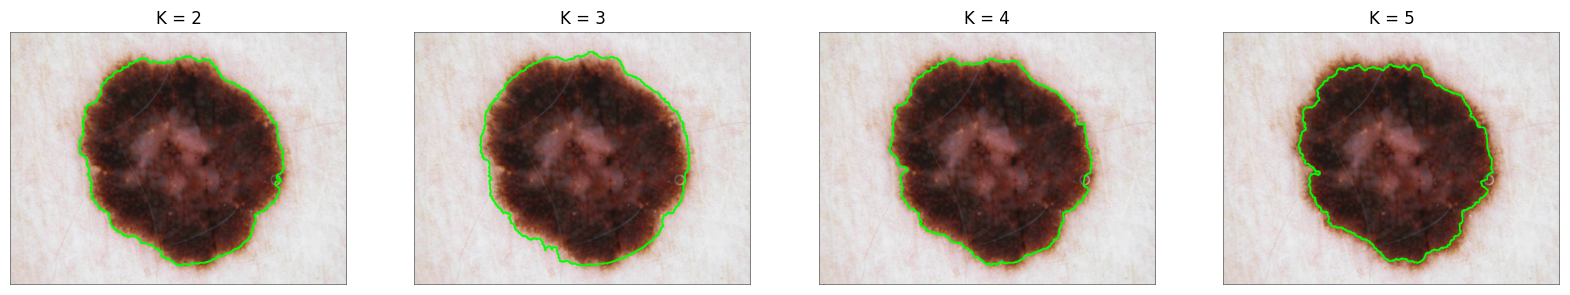

K=4 là con số 'chân ái' giúp tách đúng 4 mảng (da, viền, lõi u, nhiễu).


In [2]:
k_values = [2, 3, 4, 5]
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for i, k in enumerate(k_values):
    mask = get_kmeans_mask(clahe_color, k=k)
    axs[i].imshow(draw_contour(img, mask, (0, 255, 0)))
    axs[i].set_title(f"K = {k}")
    axs[i].axis('off')
plt.show()
print("K=4 là con số 'chân ái' giúp tách đúng 4 mảng (da, viền, lõi u, nhiễu).")


## 2. Khảo sát tham số Snakes (num_iter = 5, 35, 100)

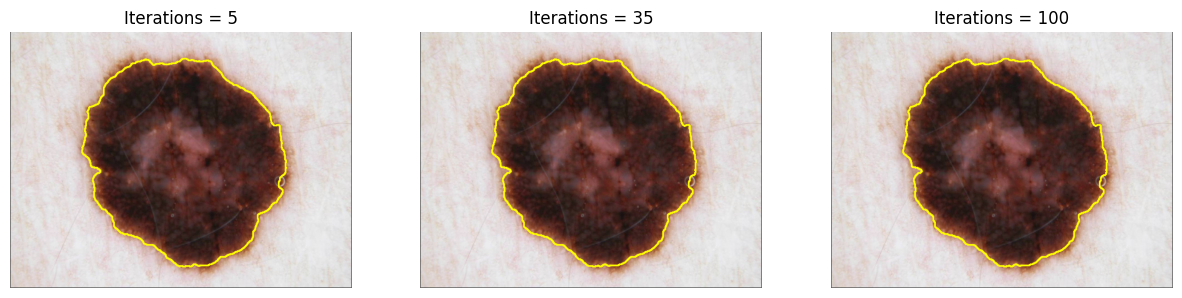

-> 5 vòng thì chưa ôm sát, 100 vòng thì bò lố ra ngoài da, 35 vòng là điểm hội tụ năng lượng hoàn hảo.


In [3]:
iters = [5, 35, 100]
kmeans_mask_optimal = get_kmeans_mask(clahe_color, k=4)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, it in enumerate(iters):
    mask = get_snakes_mask(smooth_l, kmeans_mask_optimal, num_iter=it)
    axs[i].imshow(draw_contour(img, mask, (0, 255, 255)))
    axs[i].set_title(f"Iterations = {it}")
    axs[i].axis('off')
plt.show()
print("-> 5 vòng thì chưa ôm sát, 100 vòng thì bò lố ra ngoài da, 35 vòng là điểm hội tụ năng lượng hoàn hảo.")


## 3. Ablation Study: Otsu vs K-Means vs K-Means+Snakes

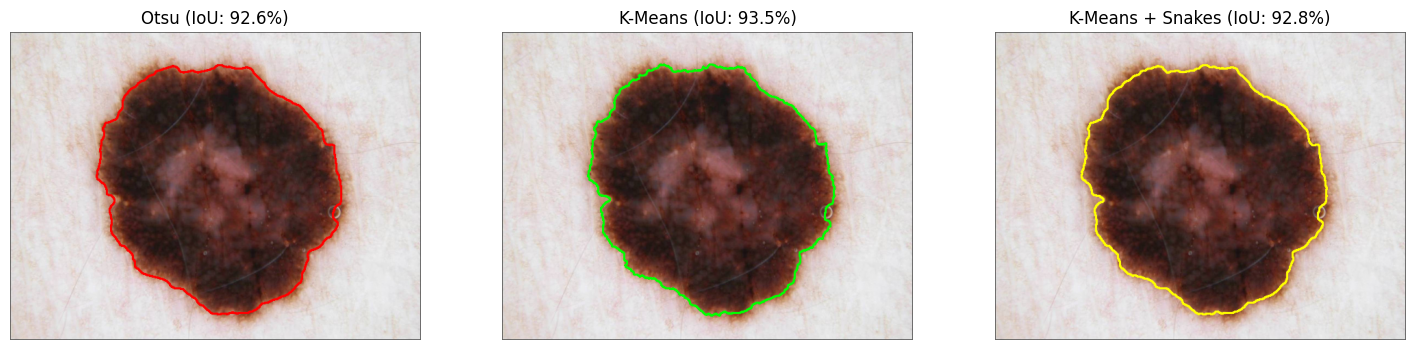

In [4]:
otsu_mask = get_otsu_mask(smooth_l)
kmeans_mask = get_kmeans_mask(clahe_color, k=4)
snakes_mask = get_snakes_mask(smooth_l, kmeans_mask, num_iter=35)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].imshow(draw_contour(img, otsu_mask, (0, 0, 255)))
axs[0].set_title(f"Otsu (IoU: {calculate_iou(otsu_mask, gt_mask)*100:.1f}%)")
axs[0].axis('off')
axs[1].imshow(draw_contour(img, kmeans_mask, (0, 255, 0)))
axs[1].set_title(f"K-Means (IoU: {calculate_iou(kmeans_mask, gt_mask)*100:.1f}%)")
axs[1].axis('off')
axs[2].imshow(draw_contour(img, snakes_mask, (0, 255, 255)))
axs[2].set_title(f"K-Means + Snakes (IoU: {calculate_iou(snakes_mask, gt_mask)*100:.1f}%)")
axs[2].axis('off')
plt.show()
